# 05 — Dual-Branch with Explicit Semantic Coherence (Kaggle T4 16GB)

> **Research Question (§0 & §5):** Does augmenting character-level Bi-LSTM representations with **explicit semantic coherence metrics** computed over frozen FastText embeddings improve zero-shot generalization to unseen wordlist DGAs (`suppobox`, `bigviktor`, `manuelita`)?  
> **Why Previous Dual-Branch Plateaued at ~0.32:** The Word-BiLSTM merely memorized specific training words (`rovnix`, `nymaim`). On unseen dictionary words (`sugar`, `claim`, `mouse`, `father`, `base`, `bus`), the model predicted benign because legitimate domains also use dictionary words.  
> **The Scientific Breakthrough:** Legitimate compounds (`fishing-shop`, `apple-tshirt`) have **high pairwise cosine similarity** between words. Wordlist DGAs concatenate **orthogonal, randomly chosen dictionary words** with near-zero or negative cosine similarity!  
> **Architecture:**
> - Branch A: Character Bi-LSTM (vocab=42, embed=64, hidden=128) &rarr; 256d
> - Branch B: FastText Word Sequence Bi-LSTM (ft_dim=300, hidden=128) &rarr; 256d
> - Branch C: **Explicit Semantic Coherence Vector (6d)** (min sim, mean sim, max sim, word count, coverage, hyphen flag) &rarr; 64d
> - Gated Attention Fusion &rarr; Classification Head

In [1]:
!pip install -q wordninja fasttext tldextract scikit-learn seaborn matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 541.6/541.6 kB 8.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 106.4/106.4 kB 6.9 MB/s eta 0:00:00


In [2]:
import os, sys, json, math, random, glob, subprocess
from pathlib import Path
import numpy as np, pandas as pd
import torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_curve, average_precision_score,
    f1_score, accuracy_score
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device} — {torch.cuda.get_device_name(0) if device=='cuda' else 'CPU'}")

# Kaggle vs Local Path Resolution
kaggle_candidates = [
    Path("/kaggle/input/dga-umudga-rhena-merged"),
    Path("/kaggle/input/datasets/walidmahmood/dga-umudga-rhena-merged"),
] + [Path(p) for p in glob.glob("/kaggle/input/*dga*")] + [Path(p) for p in glob.glob("/kaggle/input/datasets/*/*dga*")]

DATA_PROC = None
for cand in kaggle_candidates:
    if (cand / "train.csv").exists():
        DATA_PROC = cand
        break

if DATA_PROC is not None:
    WORKING = Path("/kaggle/working")
    print(f"Kaggle detected — DATA_PROC={DATA_PROC}")
else:
    BASE = Path(r"G:\dga_killer")
    DATA_PROC = BASE / "data/processed" if (BASE / "data/processed/train.csv").exists() else BASE
    WORKING = BASE / "training"
    print(f"Local detected — DATA_PROC={DATA_PROC}")

FIG_DIR = WORKING / "training_figures" if "kaggle" in str(WORKING) else WORKING / "figures"
WEIGHTS_DIR = WORKING / "training_weights" if "kaggle" in str(WORKING) else WORKING / "weights"
FIG_DIR.mkdir(parents=True, exist_ok=True)
WEIGHTS_DIR.mkdir(parents=True, exist_ok=True)

# Resolve Char Vocabulary
VOCAB_PATH = None
for v_cand in [DATA_PROC / "char_vocab.json", DATA_PROC / "data/vocab/char_vocab.json", Path(r"G:\dga_killer\data\vocab\char_vocab.json")]:
    if v_cand.exists():
        VOCAB_PATH = v_cand
        break
print(f"VOCAB_PATH={VOCAB_PATH} (exists={VOCAB_PATH.exists() if VOCAB_PATH else False})")
vocab = json.load(open(VOCAB_PATH))
char2idx = vocab["vocab"]
vocab_size = vocab["size"]
print(f"Loaded char vocab size: {vocab_size}")

Device: cuda — Tesla T4
Kaggle detected — DATA_PROC=/kaggle/input/datasets/walidmahmood/dga-umudga-rhena-merged
VOCAB_PATH=/kaggle/input/datasets/walidmahmood/dga-umudga-rhena-merged/char_vocab.json (exists=True)
Loaded char vocab size: 42


In [3]:
# Load Pretrained FastText (.bin) with auto-download
ft_bin = Path("/kaggle/working/cc.en.300.bin") if "kaggle" in str(WORKING) else Path(r"G:\dga_killer\cc.en.300.bin")

for cand in [Path("/kaggle/input/cc-en-300-bin/cc.en.300.bin"), Path("/kaggle/input/cc.en.300.bin"), Path("/kaggle/input/fasttext/cc.en.300.bin")] + [Path(x) for x in glob.glob("/kaggle/input/**/cc.en.300.bin")]:
    if cand.exists():
        ft_bin = cand
        print(f"Found FastText in Kaggle inputs: {ft_bin}")
        break

if not ft_bin.exists():
    print(f"FastText .bin not found at {ft_bin} — downloading 4.2GB compressed...")
    gz_path = Path("/kaggle/working/cc.en.300.bin.gz") if "kaggle" in str(WORKING) else Path(r"G:\dga_killer\cc.en.300.bin.gz")
    bin_target = gz_path.with_suffix("")
    if not bin_target.exists():
        try:
            subprocess.check_call(["wget", "-q", "-O", str(gz_path), "https://dl.fbaipublicfiles.com/fasttext/vectors-crawl/cc.en.300.bin.gz"])
            print("Download complete, extracting...")
            subprocess.check_call(["gunzip", "-f", str(gz_path)])
            ft_bin = bin_target
            print("Extraction complete!")
        except Exception as e:
            print(f"FastText download error: {e}")
    else:
        ft_bin = bin_target

import fasttext
print(f"Loading FastText model from {ft_bin}...")
ft = fasttext.load_model(str(ft_bin))
print("FastText loaded successfully! Frozen 300d embeddings ready.")
def get_word_vector(w):
    return ft.get_word_vector(w)

FastText .bin not found at /kaggle/working/cc.en.300.bin — downloading 4.2GB compressed...
Download complete, extracting...
Extraction complete!
Loading FastText model from /kaggle/working/cc.en.300.bin...
FastText loaded successfully! Frozen 300d embeddings ready.


In [4]:
# Word Segmentation & Semantic Coherence Feature Engineering
import wordninja

def segment_domain(sld):
    sld_str = str(sld) if (sld is not None and not (isinstance(sld, float) and math.isnan(sld))) else ""
    if not sld_str:
        return ["<unk>"]
    # Split by hyphen or underscore first
    parts = [p for p in sld_str.replace('_', '-').split('-') if p]
    words = []
    for p in parts:
        w_splits = wordninja.split(p)
        words.extend(w_splits if w_splits else [p])
    return words if words else ["<unk>"]

def compute_coherence_features(words, sld_len, sld_str=""):
    # Returns 6-dimensional feature vector:
    # [min_sim, mean_sim, max_sim, num_words_norm, word_coverage, has_hyphen]
    k = len(words)
    has_hyphen = 1.0 if '-' in sld_str else 0.0
    if k <= 1:
        # Single word: neutral coherence (neither false-benign nor false-DGA bias)
        return np.array([0.0, 0.0, 0.0, 0.1, 1.0, has_hyphen], dtype=np.float32)

    # Get unit vectors for each word
    vecs = [get_word_vector(w) for w in words]
    norms = [np.linalg.norm(v) + 1e-8 for v in vecs]
    unit_vecs = [v / n for v, n in zip(vecs, norms)]

    sims = []
    for i in range(k):
        for j in range(i + 1, k):
            sim = float(np.dot(unit_vecs[i], unit_vecs[j]))
            sims.append(sim)

    min_sim = float(np.min(sims))
    mean_sim = float(np.mean(sims))
    max_sim = float(np.max(sims))
    num_words_norm = float(min(1.0, k / 6.0))
    total_word_chars = sum(len(w) for w in words)
    coverage = float(min(1.0, total_word_chars / max(sld_len, 1)))

    return np.array([min_sim, mean_sim, max_sim, num_words_norm, coverage, has_hyphen], dtype=np.float32)

# Verification on sample domains
print("=== Semantic Coherence Verification ===")
test_cases = [
    ("fishing-shop", "Benign"),
    ("apple-tshirt", "Benign"),
    ("thebankroll", "Benign"),
    ("sugar-claim-mouse", "Matsnu (DGA)"),
    ("father-base-bus", "Matsnu (DGA)"),
    ("fieldmarry", "Suppobox (DGA)"),
    ("reportboringassumption", "Bigviktor (DGA)"),
    ("applefriends", "Manuelita (DGA)")
]
for dom, label in test_cases:
    ws = segment_domain(dom)
    feat = compute_coherence_features(ws, len(dom), dom)
    print(f"{dom:25s} [{label:15s}] -> words: {str(ws):30s} | min_sim: {feat[0]:.2f} mean_sim: {feat[1]:.2f} hyphen: {feat[5]:.0f}")

=== Semantic Coherence Verification ===
fishing-shop              [Benign         ] -> words: ['fishing', 'shop']            | min_sim: 0.22 mean_sim: 0.22 hyphen: 1
apple-tshirt              [Benign         ] -> words: ['apple', 't', 'shirt']        | min_sim: 0.07 mean_sim: 0.12 hyphen: 1
thebankroll               [Benign         ] -> words: ['the', 'bankroll']            | min_sim: 0.12 mean_sim: 0.12 hyphen: 0
sugar-claim-mouse         [Matsnu (DGA)   ] -> words: ['sugar', 'claim', 'mouse']    | min_sim: -0.02 mean_sim: 0.06 hyphen: 1
father-base-bus           [Matsnu (DGA)   ] -> words: ['father', 'base', 'bus']      | min_sim: 0.05 mean_sim: 0.12 hyphen: 1
fieldmarry                [Suppobox (DGA) ] -> words: ['field', 'marry']             | min_sim: 0.01 mean_sim: 0.01 hyphen: 0
reportboringassumption    [Bigviktor (DGA)] -> words: ['report', 'boring', 'assumption'] | min_sim: 0.01 mean_sim: 0.08 hyphen: 0
applefriends              [Manuelita (DGA)] -> words: ['apple', 'friends'

In [5]:
# Datasets & DataLoader with Balanced Stratification
train_df = pd.read_csv(DATA_PROC / "train.csv")
val_df = pd.read_csv(DATA_PROC / "val_unseen.csv")
print(f"Train rows: {len(train_df):,} | Val rows: {len(val_df):,}")

def encode_chars(sld, max_len=64, char_dropout_p=0.0):
    sld_str = str(sld) if (sld is not None and not (isinstance(sld, float) and math.isnan(sld))) else ""
    if not sld_str:
        return [0], 1
    ids = []
    for ch in sld_str[:max_len]:
        if char_dropout_p > 0 and random.random() < char_dropout_p:
            ids.append(char2idx.get("<UNK>", 1))
        else:
            ids.append(char2idx.get(ch, char2idx.get("<UNK>", 1)))
    return (ids if ids else [0]), max(len(ids), 1)

class CoherentDGADataset(Dataset):
    def __init__(self, df, is_train=True, char_dropout_p=0.05):
        self.df = df.reset_index(drop=True)
        self.is_train = is_train
        self.char_dropout_p = char_dropout_p if is_train else 0.0

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        sld = row["sld"]
        sld_str = str(sld) if (sld is not None and not (isinstance(sld, float) and math.isnan(sld))) else ""
        cids, clen = encode_chars(sld, char_dropout_p=self.char_dropout_p)
        words = segment_domain(sld)

        # Word vectors sequence for LSTM
        wvecs = np.stack([get_word_vector(w) for w in words])
        wlen = len(words)

        # Explicit Coherence vector (6d)
        cohere = compute_coherence_features(words, clen, sld_str)

        label = float(row["label_binary"])
        return (
            torch.tensor(cids, dtype=torch.long),
            torch.tensor(clen, dtype=torch.long),
            torch.tensor(wvecs, dtype=torch.float32),
            torch.tensor(wlen, dtype=torch.long),
            torch.tensor(cohere, dtype=torch.float32),
            torch.tensor(label, dtype=torch.float32)
        )

train_ds = CoherentDGADataset(train_df, is_train=True, char_dropout_p=0.05)
val_ds = CoherentDGADataset(val_df, is_train=False, char_dropout_p=0.0)

# Stratified Sampler: wordlist DGA gets 5.2x weight to reach ~1:1 wordlist:non-wordlist per batch
weights = np.where(train_df["wordlist"], 5.2, 1.0)
weights = weights / weights.sum() * len(weights)
sampler = WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)

def collate_fn(batch):
    cids, clens, wvecs, wlens, coheres, labels = zip(*batch)

    # Pad characters
    max_c = max(clens)
    padded_c = torch.zeros(len(cids), max_c, dtype=torch.long)
    for i, (ids, l) in enumerate(zip(cids, clens)):
        padded_c[i, :l] = ids

    # Pad words
    max_w = max(wlens)
    padded_w = torch.zeros(len(wvecs), max_w, 300, dtype=torch.float32)
    for i, (vec, l) in enumerate(zip(wvecs, wlens)):
        padded_w[i, :l] = vec

    return (
        padded_c,
        torch.stack(clens),
        padded_w,
        torch.stack(wlens),
        torch.stack(coheres),
        torch.stack(labels)
    )

train_loader = DataLoader(train_ds, batch_size=128, sampler=sampler, collate_fn=collate_fn, num_workers=0, pin_memory=(device=="cuda"))
val_loader = DataLoader(val_ds, batch_size=256, shuffle=False, collate_fn=collate_fn, num_workers=0, pin_memory=(device=="cuda"))
print("DataLoaders initialized (num_workers=0 for stability).")

Train rows: 1,259,799 | Val rows: 23,998
DataLoaders initialized (num_workers=0 for stability).


In [6]:
# Upgraded Dual-Branch Architecture with Semantic Coherence Fusion
class DualBranchCoherent(nn.Module):
    def __init__(self, vocab_size, char_dim=64, lstm_hidden=128, ft_dim=300, cohere_dim=6, dropout=0.4):
        super().__init__()
        # Branch A: Character Bi-LSTM
        self.char_embed = nn.Embedding(vocab_size, char_dim, padding_idx=0)
        self.char_lstm = nn.LSTM(char_dim, lstm_hidden, batch_first=True, bidirectional=True)
        self.char_drop = nn.Dropout(dropout)

        # Branch B: Word Sequence Bi-LSTM
        self.word_lstm = nn.LSTM(ft_dim, lstm_hidden, batch_first=True, bidirectional=True)
        self.word_drop = nn.Dropout(dropout)

        # Branch C: Semantic Coherence MLP
        self.cohere_mlp = nn.Sequential(
            nn.Linear(cohere_dim, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 64),
            nn.ReLU()
        )

        # Adaptive Gating: determines trust between Char branch vs Word/Coherence branch
        total_repr = (lstm_hidden * 2) + (lstm_hidden * 2) + 64  # 256 + 256 + 64 = 576
        self.gate = nn.Sequential(
            nn.Linear(total_repr, 1),
            nn.Sigmoid()
        )

        # Classification Head
        self.head = nn.Sequential(
            nn.Linear(total_repr, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1)
        )

    def forward(self, char_ids, char_lens, w_seqs, w_lens, coheres, return_gate=False):
        # Char Branch
        c_emb = self.char_embed(char_ids)
        packed_c = pack_padded_sequence(c_emb, char_lens.cpu(), batch_first=True, enforce_sorted=False)
        _, (h_c, _) = self.char_lstm(packed_c)
        h_char = torch.cat([h_c[0], h_c[1]], dim=1)  # [B, 256]
        h_char = self.char_drop(h_char)

        # Word Branch
        packed_w = pack_padded_sequence(w_seqs, w_lens.cpu(), batch_first=True, enforce_sorted=False)
        _, (h_w, _) = self.word_lstm(packed_w)
        h_word = torch.cat([h_w[0], h_w[1]], dim=1)  # [B, 256]
        h_word = self.word_drop(h_word)

        # Coherence Branch
        h_cohere = self.cohere_mlp(coheres)  # [B, 64]

        # Fused representation with learned gate
        combined = torch.cat([h_char, h_word, h_cohere], dim=1)
        g = self.gate(combined)  # [B, 1]

        # Scale char by g, and word/cohere by (1-g)
        fused = torch.cat([g * h_char, (1.0 - g) * h_word, h_cohere], dim=1)
        logit = self.head(fused).squeeze(1)

        if return_gate:
            return logit, g.squeeze(1)
        return logit

model = DualBranchCoherent(vocab_size=vocab_size).to(device)
print(model)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total trainable parameters: {total_params:,} (~{total_params/1e6:.2f}M) — fast, robust, regularized.")

DualBranchCoherent(
  (char_embed): Embedding(42, 64, padding_idx=0)
  (char_lstm): LSTM(64, 128, batch_first=True, bidirectional=True)
  (char_drop): Dropout(p=0.4, inplace=False)
  (word_lstm): LSTM(300, 128, batch_first=True, bidirectional=True)
  (word_drop): Dropout(p=0.4, inplace=False)
  (cohere_mlp): Sequential(
    (0): Linear(in_features=6, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.4, inplace=False)
    (3): Linear(in_features=64, out_features=64, bias=True)
    (4): ReLU()
  )
  (gate): Sequential(
    (0): Linear(in_features=576, out_features=1, bias=True)
    (1): Sigmoid()
  )
  (head): Sequential(
    (0): Linear(in_features=576, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.4, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.4, inplace=False)
    (6): Linear(in_features=64, out_features=1, bias=True)
  )
)
Total trainable parameters: 729,026 (~0.73M) — fast, robust

In [7]:
# Training Loop with Val Wordlist Macro-Recall Checkpointing
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=2)

def eval_dual(loader, mdl):
    mdl.eval()
    ys, yps, yprs, gs = [], [], [], []
    with torch.no_grad():
        for cids, clens, wseqs, wlens, coh, labels in loader:
            cids, clens, wseqs, wlens, coh = cids.to(device), clens.to(device), wseqs.to(device), wlens.to(device), coh.to(device)
            logits, gate_val = mdl(cids, clens, wseqs, wlens, coh, return_gate=True)
            probs = torch.sigmoid(logits)
            ys.append(labels.cpu().numpy())
            yps.append((probs >= 0.5).float().cpu().numpy())
            yprs.append(probs.cpu().numpy())
            gs.append(gate_val.cpu().numpy())
    y_true = np.concatenate(ys)
    y_pred = np.concatenate(yps)
    y_proba = np.concatenate(yprs)
    y_gate = np.concatenate(gs)
    return {
        "acc": accuracy_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "auc": roc_auc_score(y_true, y_proba),
        "ap": average_precision_score(y_true, y_proba),
        "y_true": y_true,
        "y_pred": y_pred,
        "y_proba": y_proba,
        "y_gate": y_gate
    }

EPOCHS = 8
best_wl_macro = -1.0
best_weights_path = WEIGHTS_DIR / "dual_branch_coherent_best.pt"

val_fams = val_df["family"].values
WORDLIST_FAMS = ["suppobox", "bigviktor", "manuelita"]
NON_WORDLIST_FAMS = ["ranbyus", "zeus-newgoz"]

print("=== STARTING TRAINING (Dual-Branch Coherent) ===")
for epoch in range(1, EPOCHS + 1):
    model.train()
    total_loss = 0.0
    for cids, clens, wseqs, wlens, coh, labels in train_loader:
        cids, clens, wseqs, wlens, coh, labels = cids.to(device), clens.to(device), wseqs.to(device), wlens.to(device), coh.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(cids, clens, wseqs, wlens, coh)
        # Label smoothing: prevents overconfident predictions, reduces train/val gap
        smooth_labels = labels * 0.9 + 0.05
        loss = criterion(logits, smooth_labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item() * len(labels)

    train_loss = total_loss / len(train_ds)
    val_res = eval_dual(val_loader, model)

    # Wordlist macro recall
    wl_recs = []
    for f in WORDLIST_FAMS:
        m = (val_fams == f)
        if m.sum() > 0:
            wl_recs.append((val_res["y_pred"][m] == 1).mean())
    wl_macro = float(np.mean(wl_recs)) if wl_recs else 0.0

    # Non-wordlist recall
    nw_recs = []
    for f in NON_WORDLIST_FAMS:
        m = (val_fams == f)
        if m.sum() > 0:
            nw_recs.append((val_res["y_pred"][m] == 1).mean())
    nw_macro = float(np.mean(nw_recs)) if nw_recs else 0.0

    print(f"Epoch {epoch:02d} — Train Loss: {train_loss:.4f} | Val F1: {val_res['f1']:.4f} AUC: {val_res['auc']:.4f} | WL Macro: {wl_macro:.4f} ({'/'.join(f'{r:.2f}' for r in wl_recs)}) | NW: {nw_macro:.3f}")
    scheduler.step(wl_macro)

    if wl_macro > best_wl_macro:
        best_wl_macro = wl_macro
        torch.save(model.state_dict(), best_weights_path)
        print(f"  --> Saved new best checkpoint: WL Macro = {best_wl_macro:.4f}")

print(f"\nTraining Complete! Best Val Wordlist Macro-Recall: {best_wl_macro:.4f}")
model.load_state_dict(torch.load(best_weights_path, map_location=device))

=== STARTING TRAINING (Dual-Branch Coherent) ===
Epoch 01 — Train Loss: 0.3700 | Val F1: 0.6815 AUC: 0.7631 | WL Macro: 0.3484 (0.32/0.40/0.32) | NW: 1.000
  --> Saved new best checkpoint: WL Macro = 0.3484
Epoch 02 — Train Loss: 0.3344 | Val F1: 0.6708 AUC: 0.7547 | WL Macro: 0.2835 (0.26/0.31/0.29) | NW: 0.999
Epoch 03 — Train Loss: 0.3230 | Val F1: 0.6593 AUC: 0.7473 | WL Macro: 0.2614 (0.25/0.22/0.32) | NW: 1.000
Epoch 04 — Train Loss: 0.3139 | Val F1: 0.6567 AUC: 0.7448 | WL Macro: 0.2257 (0.21/0.22/0.25) | NW: 0.999
Epoch 05 — Train Loss: 0.3052 | Val F1: 0.6516 AUC: 0.7410 | WL Macro: 0.2232 (0.19/0.18/0.29) | NW: 1.000
Epoch 06 — Train Loss: 0.3012 | Val F1: 0.6620 AUC: 0.7529 | WL Macro: 0.2400 (0.22/0.22/0.28) | NW: 0.999
Epoch 07 — Train Loss: 0.2974 | Val F1: 0.6569 AUC: 0.7411 | WL Macro: 0.2309 (0.23/0.18/0.28) | NW: 0.999
Epoch 08 — Train Loss: 0.2936 | Val F1: 0.6573 AUC: 0.7413 | WL Macro: 0.2317 (0.22/0.19/0.29) | NW: 0.999

Training Complete! Best Val Wordlist Macro-

<All keys matched successfully>


VAL-UNSEEN OVERALL (Dual-Branch Coherent):
Accuracy: 0.7246 | F1: 0.6815 | AUC: 0.7631 | AP: 0.8213

Classification Report:
              precision    recall  f1-score   support

      Benign      0.677     0.860     0.758     11999
         DGA      0.808     0.589     0.681     11999

    accuracy                          0.725     23998
   macro avg      0.742     0.725     0.719     23998
weighted avg      0.742     0.725     0.719     23998


Per-Family Recall (Val-Unseen):
  bigviktor       n=2000  Recall: 0.401 (Wordlist)
  kraken          n=2000  Recall: 0.490 (Non-Wordlist)
  legit           n=11999  Accuracy: 0.860
  manuelita       n=1999  Recall: 0.323 (Wordlist)
  ranbyus         n=2000  Recall: 1.000 (Non-Wordlist)
  suppobox        n=2000  Recall: 0.322 (Wordlist)
  zeus-newgoz     n=2000  Recall: 1.000 (Non-Wordlist)

Gate Trust (Weight on Char Branch, 0=Word 1=Char):
  Overall mean: 0.210
  Wordlist DGA mean: 0.248
  Non-wordlist DGA mean: 0.100
  Benign mean: 0.246



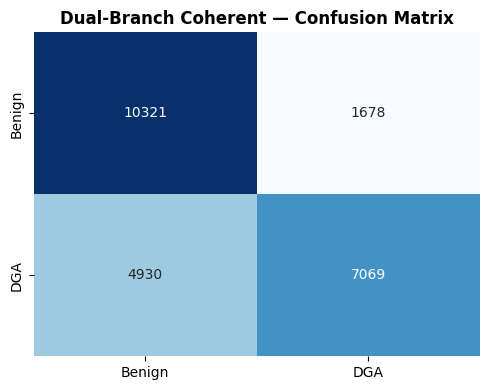

Exported metrics to: results/baselines/dual_coherent_metrics.json
Exported metrics to: /kaggle/working/training_weights/dual_coherent_metrics.json
Exported metrics to: /kaggle/working/dual_coherent_metrics.json


In [8]:
# Comprehensive Final Evaluation
val_res = eval_dual(val_loader, model)
y_true_val = val_res["y_true"]
y_pred_val = val_res["y_pred"]
y_proba_val = val_res["y_proba"]

print("\nVAL-UNSEEN OVERALL (Dual-Branch Coherent):")
print(f"Accuracy: {val_res['acc']:.4f} | F1: {val_res['f1']:.4f} | AUC: {val_res['auc']:.4f} | AP: {val_res['ap']:.4f}")
print("\nClassification Report:")
print(classification_report(y_true_val, y_pred_val, target_names=["Benign", "DGA"], digits=3))

# Per-family breakdown
per_fam_records = {}
print("\nPer-Family Recall (Val-Unseen):")
for fam in sorted(val_df["family"].unique()):
    mask = (val_df["family"] == fam)
    if fam == "legit":
        score = float((y_pred_val[mask.values] == 0).mean())
        print(f"  {fam:15s} n={mask.sum():4d}  Accuracy: {score:.3f}")
    else:
        score = float((y_pred_val[mask.values] == 1).mean())
        is_wl = bool(val_df.loc[mask, "wordlist"].iloc[0])
        wl_label = "Wordlist" if is_wl else "Non-Wordlist"
        per_fam_records[fam] = score
        print(f"  {fam:15s} n={mask.sum():4d}  Recall: {score:.3f} ({wl_label})")

# Gate Analysis
wl_mask = val_df["wordlist"].values
legit_mask = (val_df["family"] == "legit").values
print(f"\nGate Trust (Weight on Char Branch, 0=Word 1=Char):")
print(f"  Overall mean: {val_res['y_gate'].mean():.3f}")
print(f"  Wordlist DGA mean: {val_res['y_gate'][wl_mask].mean():.3f}")
print(f"  Non-wordlist DGA mean: {val_res['y_gate'][~wl_mask & ~legit_mask].mean():.3f}")
print(f"  Benign mean: {val_res['y_gate'][legit_mask].mean():.3f}")

# Threshold Sweep for operational deployment
print("\n--- Operational Decision Threshold Sweep ---")
for thr in [0.50, 0.40, 0.35, 0.30, 0.25, 0.20, 0.15]:
    yp = (y_proba_val >= thr).astype(int)
    wl_sc = [float((yp[val_df["family"] == f] == 1).mean()) for f in WORDLIST_FAMS if (val_df["family"] == f).sum() > 0]
    wl_m = np.mean(wl_sc)
    b_acc = float((yp[val_df["family"] == "legit"] == 0).mean())
    f1_t = f1_score(y_true_val, yp)
    print(f"  Threshold {thr:.2f} -> Wordlist Macro: {wl_m:.3f} {['%.2f'%x for x in wl_sc]} | Benign Acc: {b_acc:.3f} | F1: {f1_t:.3f}")

# Confusion Matrix
cm = confusion_matrix(y_true_val, y_pred_val, labels=[0, 1])
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, xticklabels=["Benign", "DGA"], yticklabels=["Benign", "DGA"])
plt.title("Dual-Branch Coherent — Confusion Matrix", fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "dual_coherent_confusion.png", dpi=300, bbox_inches="tight")
plt.show()

# Save Metrics JSON
metrics = {
    "model": "dual_branch_coherent_fasttext",
    "val": {
        "acc": float(val_res["acc"]),
        "f1": float(val_res["f1"]),
        "auc": float(val_res["auc"]),
        "wordlist_macro_recall": float(best_wl_macro)
    },
    "per_family_recall": per_fam_records
}
for p in [Path("results/baselines/dual_coherent_metrics.json"), WEIGHTS_DIR / "dual_coherent_metrics.json", WORKING / "dual_coherent_metrics.json"]:
    try:
        p.parent.mkdir(parents=True, exist_ok=True)
        with open(p, "w") as f:
            json.dump(metrics, f, indent=2)
        print(f"Exported metrics to: {p}")
    except Exception:
        pass